In [54]:
import pandas as pd

df = pd.read_csv("/covid_data.csv")
df.head()





,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/10DCGj9s00k-GH3KmRDM8T6ZZsVADEzN6C2S2Rmxoqm4/edit#gid=0


In [58]:
#Limpieza de datos
# Convertir fecha (si existe columna tipo date)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Eliminar nulos
df = df.dropna()

# Verificar
df.isnull().sum()


,0
Province/State,0
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [59]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

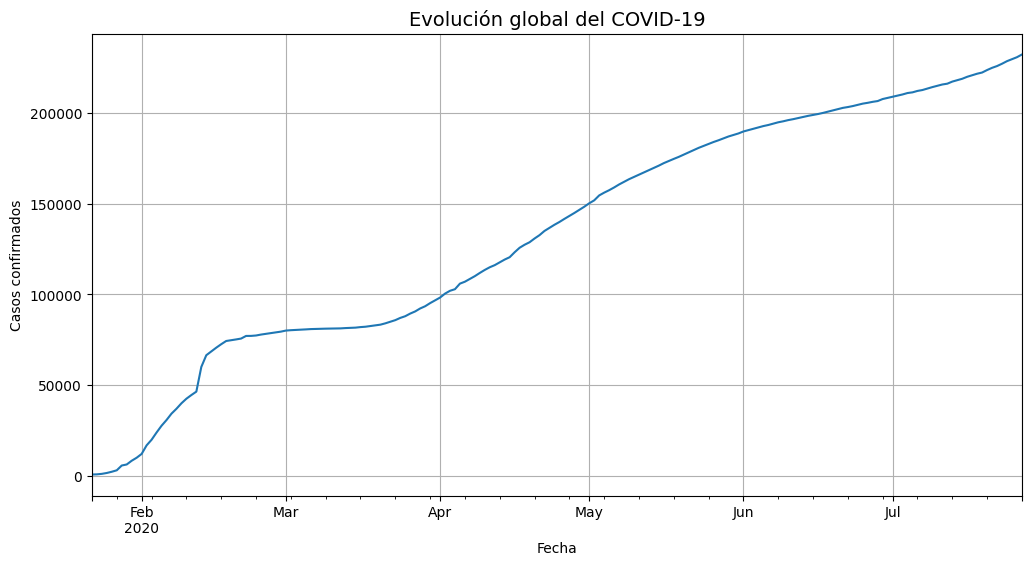

In [60]:
#Evolucion Global

df_global = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(12,6))
df_global.plot()

plt.title("Evolución global del COVID-19", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Casos confirmados")
plt.grid()

plt.show()

In [61]:
#Top paises

top_paises = df.groupby('Province/State')['Confirmed'].sum().sort_values(ascending=False).head(10)
print(top_paises)

Province/State
Hubei               11473248
Quebec               4934478
Ontario              3100515
Alberta               751219
New South Wales       384636
British Columbia      298207
Victoria              279524
Guangdong             268051
French Guiana         226554
Henan                 222581
Name: Confirmed, dtype: int64


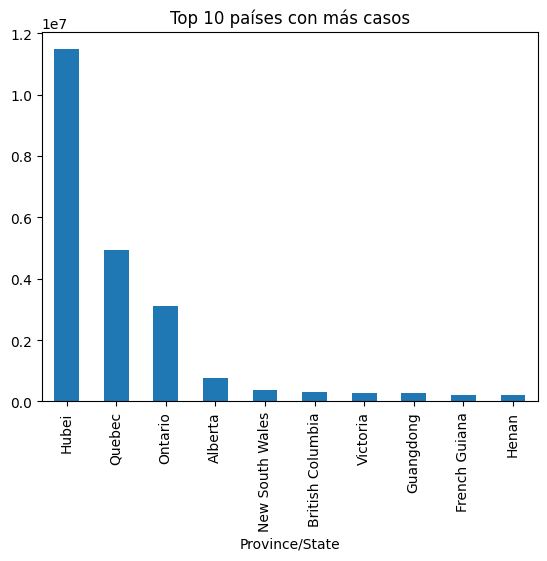

In [62]:
top_paises.plot(kind='bar')
plt.title("Top 10 países con más casos")
plt.show()

In [63]:
df.dtypes

,0
Province/State,object
Country/Region,object
Lat,float64
Long,float64
Date,datetime64[ns]
Confirmed,int64
Deaths,int64
Recovered,int64
Active,int64
WHO Region,object


In [64]:
df.columns = df.columns.str.lower().str.replace('/', '_').str.replace(' ', '_')
df.columns

Index(['province_state', 'country_region', 'lat', 'long', 'date', 'confirmed',
       'deaths', 'recovered', 'active', 'who_region'],
      dtype='object')

In [65]:
df['country_region'].unique()

array(['Australia', 'Canada', 'China', 'Denmark', 'Greenland', 'France',
       'Netherlands', 'United Kingdom'], dtype=object)

<Figure size 1200x600 with 0 Axes>

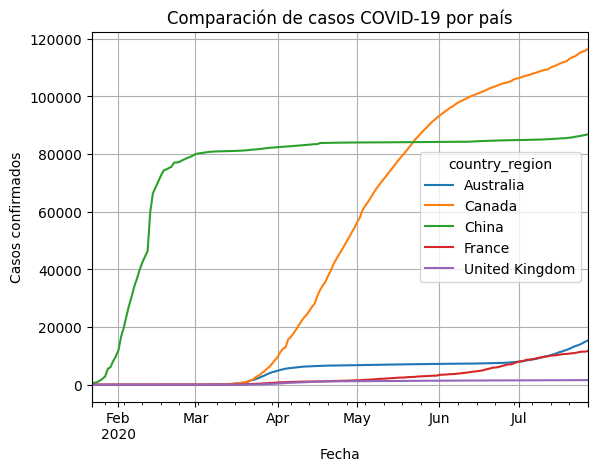

In [66]:
paises = ['Australia', 'Canada', 'China', 'France', 'United Kingdom']

df_filtrado = df[df['country_region'].isin(paises)]

df_grouped = df_filtrado.groupby(['date','country_region'])['confirmed'].sum().unstack()

plt.figure(figsize=(12,6))
df_grouped.plot()

plt.title("Comparación de casos COVID-19 por país")
plt.xlabel("Fecha")
plt.ylabel("Casos confirmados")
plt.grid()

plt.show()

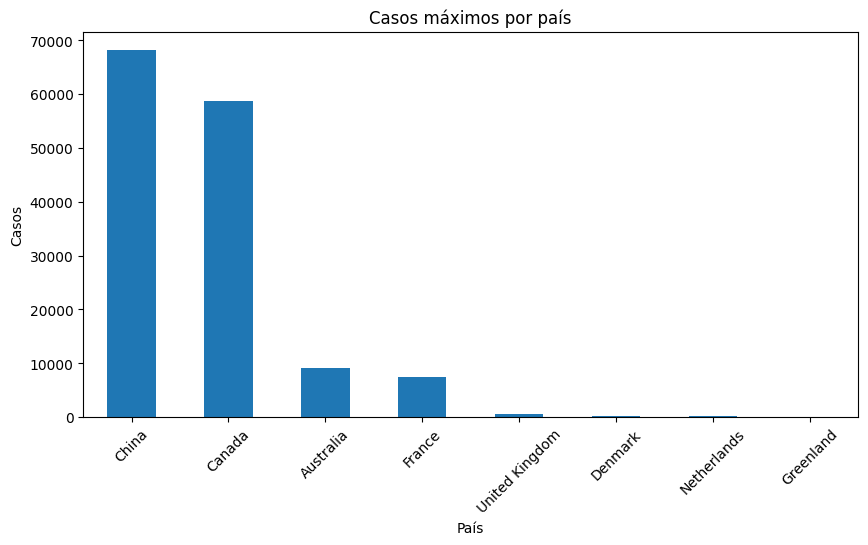

In [67]:
#Top paises
top = df.groupby('country_region')['confirmed'].max().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top.plot(kind='bar')

plt.title("Casos máximos por país")
plt.xlabel("País")
plt.ylabel("Casos")

plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_69224/2713183515.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['daily_cases'] = df.groupby('country_region')['confirmed'].diff()


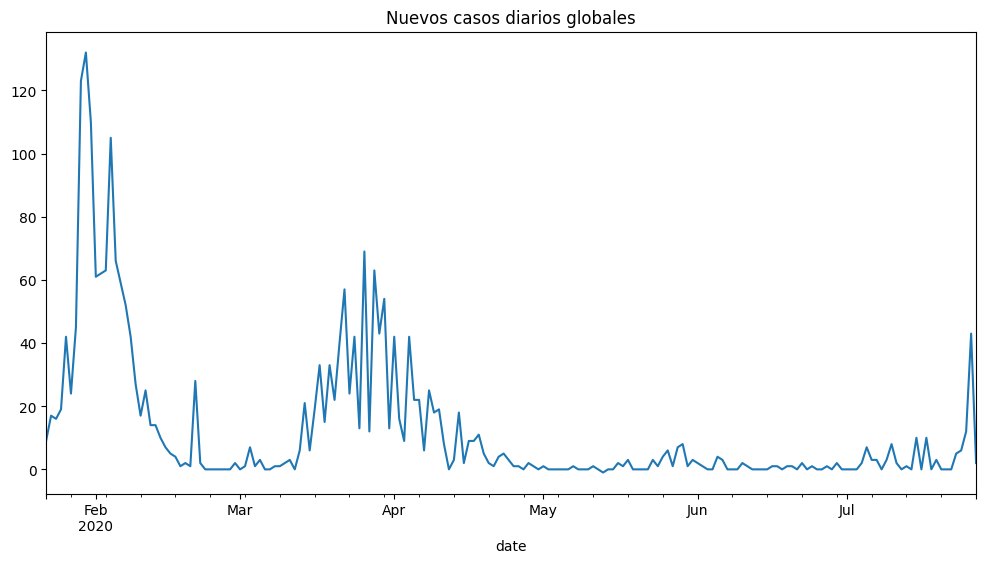

In [68]:
#Nuevos casos diarios
df['daily_cases'] = df.groupby('country_region')['confirmed'].diff()

df.groupby('date')['daily_cases'].sum().plot(figsize=(12,6))
plt.title("Nuevos casos diarios globales")
plt.show()